# Загрузка данных

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spsayakpaul/arxiv-paper-abstracts")

print("Path to dataset files:", path)

100%|██████████| 44.6M/44.6M [00:00<00:00, 59.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/spsayakpaul/arxiv-paper-abstracts/versions/2


In [ ]:
import pandas as pd
# from kagglehub import KaggleDatasetAdapter

In [ ]:
df = pd.read_csv(path + "/arxiv_data.csv")

In [ ]:
df.head()

,titles,summaries,terms
0,Survey on Semantic Stereo Matching / Semantic ...,Stereo matching is one of the widely used tech...,"['cs.CV', 'cs.LG']"
1,FUTURE-AI: Guiding Principles and Consensus Re...,The recent advancements in artificial intellig...,"['cs.CV', 'cs.AI', 'cs.LG']"
2,Enforcing Mutual Consistency of Hard Regions f...,"In this paper, we proposed a novel mutual cons...","['cs.CV', 'cs.AI']"
3,Parameter Decoupling Strategy for Semi-supervi...,Consistency training has proven to be an advan...,['cs.CV']
4,Background-Foreground Segmentation for Interio...,"To ensure safety in automated driving, the cor...","['cs.CV', 'cs.LG']"


In [ ]:
df['titles'][1]

'FUTURE-AI: Guiding Principles and Consensus Recommendations for Trustworthy Artificial Intelligence in Future Medical Imaging'

In [ ]:
df['summaries'][1][:500]

"The recent advancements in artificial intelligence (AI) combined with the\nextensive amount of data generated by today's clinical systems, has led to the\ndevelopment of imaging AI solutions across the whole value chain of medical\nimaging, including image reconstruction, medical image segmentation,\nimage-based diagnosis and treatment planning. Notwithstanding the successes and\nfuture potential of AI in medical imaging, many stakeholders are concerned of\nthe potential risks and ethical implications"

In [ ]:
df.iloc[1000]

,1000
titles,Dynamic Multiscale Tree Learning Using Ensembl...
summaries,We introduce a dynamic multiscale tree (DMT) a...
terms,['cs.CV']


In [ ]:
# df.shape # можно отдельно выводить размер и название столбцов, а можно просто describe()
# df.columns
df.describe()

,titles,summaries,terms
count,51774,51774,51774
unique,38972,38979,3157
top,Deep Reinforcement Learning: An Overview,Astounding results from Transformer models on ...,['cs.CV']
freq,7,7,17369


In [ ]:
df['terms'].value_counts()

,count
terms,
['cs.CV'],17369
"['cs.LG', 'stat.ML']",5251
['cs.LG'],2732
"['cs.CV', 'cs.LG']",2067
"['cs.LG', 'cs.AI']",1702
...,...
"['cs.LG', 'cond-mat.mtrl-sci', 'cs.CE', 'physics.comp-ph', 'stat.ML']",1
"['stat.ML', 'cs.AI', 'cs.CE', 'cs.CV', 'cs.LG']",1
"['stat.ML', 'cs.AI', 'cs.SI']",1


In [ ]:
df['terms'].str.contains('physics').value_counts()[True]

np.int64(492)

In [ ]:
df['terms'][1]

"['cs.CV', 'cs.AI', 'cs.LG']"

In [ ]:
df['terms'][1][2:-2].split(', ')

["cs.CV'", "'cs.AI'", "'cs.LG"]

In [ ]:
df2 = df[df['terms'].apply(lambda x: len(x[2:-2].split(', ')) == 1 )] # Оставляем строки, содержащие одну рубрику

In [ ]:
df2['terms'].value_counts()

,count
terms,
['cs.CV'],17369
['cs.LG'],2732
['stat.ML'],181


Датасет сильно уменьшился, особенно для последней рубрики...

Будем считать, что первая рубрика в списке -- главная, ее и оставим

In [ ]:
import re

In [ ]:
df3 = df
df3['terms'] = df3['terms'].str.replace(r'(,\s).*', ']', regex=True)
# df3['terms'].str.replace(r"\b,.*", '')
# df3.replace({'terms': r'^ba.$'}, {'terms': ''}, regex=True)
df3['terms'].value_counts()

,count
terms,
['cs.CV'],28101
['cs.LG'],20751
['stat.ML'],2922


In [ ]:
'''Уже лучше'''

**Описание рубрик**

**cs.CV** (Computer Vision and Pattern Recognition)

Covers image processing, computer vision, pattern recognition, and scene understanding. Roughly includes material in ACM Subject Classes I.2.10, I.4, and I.5.

**cs.LG** (Machine Learning)


Papers on all aspects of machine learning research (supervised, unsupervised, reinforcement learning, bandit problems, and so on) including also robustness, explanation, fairness, and methodology. cs.LG is also an appropriate primary category for applications of machine learning methods.


**stat.ML** (Machine Learning)

Covers machine learning papers (supervised, unsupervised, semi-supervised learning, graphical models, reinforcement learning, bandits, high dimensional inference, etc.) with a statistical or theoretical grounding

In [ ]:
df3.iloc[1000]

,1000
titles,Dynamic Multiscale Tree Learning Using Ensembl...
summaries,We introduce a dynamic multiscale tree (DMT) a...
terms,['cs.CV']


In [ ]:
dataset = df3

Посмотрим на данные...

In [ ]:
text = df3['summaries'][1000]
text

'We introduce a dynamic multiscale tree (DMT) architecture that learns how to\nleverage the strengths of different existing classifiers for supervised\nmulti-label image segmentation. Unlike previous works that simply aggregate or\ncascade classifiers for addressing image segmentation and labeling tasks, we\npropose to embed strong classifiers into a tree structure that allows\nbi-directional flow of information between its classifier nodes to gradually\nimprove their performances. Our DMT is a generic classification model that\ninherently embeds different cascades of classifiers while enhancing learning\ntransfer between them to boost up their classification accuracies.\nSpecifically, each node in our DMT can nest a Structured Random Forest (SRF)\nclassifier or a Bayesian Network (BN) classifier. The proposed SRF-BN DMT\narchitecture has several appealing properties. First, while SRF operates at a\npatch-level (regular image region), BN operates at the super-pixel level\n(irregular im

Текст довольно чистый, но встречаются символы, нужно очистить...

In [ ]:
from bs4 import BeautifulSoup

In [ ]:
soup = BeautifulSoup(text, 'html.parser')
# soup.get_text()

In [ ]:
for data in soup(['style', 'script']):
  data.decompose()
' '.join(soup.stripped_strings)

'We introduce a dynamic multiscale tree (DMT) architecture that learns how to\nleverage the strengths of different existing classifiers for supervised\nmulti-label image segmentation. Unlike previous works that simply aggregate or\ncascade classifiers for addressing image segmentation and labeling tasks, we\npropose to embed strong classifiers into a tree structure that allows\nbi-directional flow of information between its classifier nodes to gradually\nimprove their performances. Our DMT is a generic classification model that\ninherently embeds different cascades of classifiers while enhancing learning\ntransfer between them to boost up their classification accuracies.\nSpecifically, each node in our DMT can nest a Structured Random Forest (SRF)\nclassifier or a Bayesian Network (BN) classifier. The proposed SRF-BN DMT\narchitecture has several appealing properties. First, while SRF operates at a\npatch-level (regular image region), BN operates at the super-pixel level\n(irregular im

In [ ]:
!pip install clean-text

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171031 sha256=1a060a61908d48949cbd5134c29b202ec5a354685893e3a89137059cc16c4f8d
  Stored in directory: /root/.cache/pip/wheels/bd/22/e5/b69726d5e1a19795ecd3b3e7464b16c0f1d019aa94ff1c8578
Successfully built emoji


In [ ]:
from cleantext import clean

In [ ]:
clean(text)

'we introduce a dynamic multiscale tree (dmt) architecture that learns how to\nleverage the strengths of different existing classifiers for supervised\nmulti-label image segmentation. unlike previous works that simply aggregate or\ncascade classifiers for addressing image segmentation and labeling tasks, we\npropose to embed strong classifiers into a tree structure that allows\nbi-directional flow of information between its classifier nodes to gradually\nimprove their performances. our dmt is a generic classification model that\ninherently embeds different cascades of classifiers while enhancing learning\ntransfer between them to boost up their classification accuracies.\nspecifically, each node in our dmt can nest a structured random forest (srf)\nclassifier or a bayesian network (bn) classifier. the proposed srf-bn dmt\narchitecture has several appealing properties. first, while srf operates at a\npatch-level (regular image region), bn operates at the super-pixel level\n(irregular im

In [ ]:
# pattern = r'([A-Za-z0-9]+[.-_])*[A-Za-z0-9]+@[A-Za-z0-9-]+(\.[A-Z|a-z]{2,})+'
re.sub('\n', ' ', text)

'We introduce a dynamic multiscale tree (DMT) architecture that learns how to leverage the strengths of different existing classifiers for supervised multi-label image segmentation. Unlike previous works that simply aggregate or cascade classifiers for addressing image segmentation and labeling tasks, we propose to embed strong classifiers into a tree structure that allows bi-directional flow of information between its classifier nodes to gradually improve their performances. Our DMT is a generic classification model that inherently embeds different cascades of classifiers while enhancing learning transfer between them to boost up their classification accuracies. Specifically, each node in our DMT can nest a Structured Random Forest (SRF) classifier or a Bayesian Network (BN) classifier. The proposed SRF-BN DMT architecture has several appealing properties. First, while SRF operates at a patch-level (regular image region), BN operates at the super-pixel level (irregular image region), 

In [ ]:
re.sub('\n', ' ', df['summaries'][1234])

'We explore the efficiency of the CRF inference module beyond image level semantic segmentation. The key idea is to combine the best of two worlds of semantic co-labeling and exploiting more expressive models. Similar to [Alvarez14] our formulation enables us perform inference over ten thousand images within seconds. On the other hand, it can handle higher-order clique potentials similar to [vineet2014] in terms of region-level label consistency and context in terms of co-occurrences. We follow the mean-field updates for higher order potentials similar to [vineet2014] and extend the spatial smoothness and appearance kernels [DenseCRF13] to address video data inspired by [Alvarez14]; thus making the system amenable to perform video semantic segmentation most effectively.'

In [ ]:
re.sub('\n', ' ', clean(df['summaries'][1234], no_digits=True, no_punct=True, replace_with_digit=''))

'we explore the efficiency of the crf inference module beyond image level semantic segmentation the key idea is to combine the best of two worlds of semantic colabeling and exploiting more expressive models similar to alvarez our formulation enables us perform inference over ten thousand images within seconds on the other hand it can handle higherorder clique potentials similar to vineet in terms of regionlevel label consistency and context in terms of cooccurrences we follow the meanfield updates for higher order potentials similar to vineet and extend the spatial smoothness and appearance kernels densecrf to address video data inspired by alvarez thus making the system amenable to perform video semantic segmentation most effectively'

# Очистка, токенизация

In [ ]:
import spacy

In [ ]:
nlp = spacy.load("en_core_web_sm")
stopwords = nlp.Defaults.stop_words
# print(f'Spacy english stopwords size: {len(stopwords)}', end='\n\n')
# ' '.join(stopwords)

In [ ]:
doc = nlp(text)
for i, token in enumerate(doc):
    print(token.text)
    if i > 20:
      print('...')
      break

We
introduce
a
dynamic
multiscale
tree
(
DMT
)
architecture
that
learns
how
to


leverage
the
strengths
of
different
existing
classifiers
...


In [ ]:
%%time

dataset['cleaned_text'] = dataset['summaries'].apply(
    lambda x: ' '.join(
        token.lemma_.lower() for token in nlp(x) if
        not token.is_stop
        and not token.is_punct
        and not token.is_digit
        and not token.like_email
        and not token.like_num
        and not token.is_space
    )
)
dataset.sample(5)

CPU times: user 41min 10s, sys: 6.59 s, total: 41min 17s
Wall time: 41min 42s


,titles,summaries,terms,cleaned_text
19702,Sub-Instruction Aware Vision-and-Language Navi...,Vision-and-language navigation requires an age...,['cs.CV'],vision language navigation require agent navig...
39278,Comparison of different convolutional neural n...,"Recently, much attention has been devoted to f...",['cs.CV'],recently attention devote find highly efficien...
6903,MixConv: Mixed Depthwise Convolutional Kernels,Depthwise convolution is becoming increasingly...,['cs.CV'],depthwise convolution increasingly popular mod...
16470,Improving learnability of neural networks: add...,Over-parameterized deep neural networks have p...,['cs.LG'],parameterize deep neural network prove able le...
41113,Learning Disentangled Feature Representation f...,Hybrid-distorted image restoration (HD-IR) is ...,['cs.CV'],hybrid distort image restoration hd ir dedicat...


Выполнялось больше получаса...

In [ ]:
# df_downsample = df.sample(frac=0.4, weights='counts', axis=0) # можно
# уменьшить размер выборки %%

In [ ]:
dataset.to_csv('cleaned.csv', index=False) # сохраним, чтобы не чистить снова

In [ ]:
import csv

In [ ]:
dataset = pd.read_csv('cleaned.csv', on_bad_lines='warn')
# dataset = pd.read_csv('cleaned.csv', on_bad_lines='warn')
# dataset = pd.read_csv('cleaned.csv', quoting=csv.QUOTE_NONE)
# dataset = .to_csv('cleaned.csv', index=False)

In [ ]:
dataset.sample(5)

,titles,summaries,terms,cleaned_text
4002,"Unsupervised Discovery, Control, and Disentang...",Our work focuses on unsupervised and generativ...,['cs.CV'],work focus unsupervised generative method addr...
2569,EEMC: Embedding Enhanced Multi-tag Classification,The recently occurred representation learning ...,['cs.LG'],recently occur representation learning attract...
10994,GenRadar: Self-supervised Probabilistic Camera...,Autonomous systems require a continuous and de...,['cs.CV'],autonomous system require continuous dependabl...
9124,Learning to Localize Actions from Moments,"With the knowledge of action moments (i.e., tr...",['cs.CV'],knowledge action moment i.e. trim video clip c...
13795,Training spiking neural networks using reinfor...,Neurons in the brain communicate with each oth...,['cs.LG'],neuron brain communicate discrete action spike...


In [ ]:
dataset['cleaned_text'][600]

'accurate segmentation optic disc od cup oc)in fundus image different dataset critical glaucoma disease screening cross domain discrepancy domain shift hinder generalization deep neural network work different domain dataset work present unsupervised domain adaptation framework call boundary entropy drive adversarial learning beal improve od oc segmentation performance especially ambiguous boundary region particular propose beal frame work utilize adversarial learning encourage boundary prediction mask probability entropy map uncertainty map target domain similar source one generate accurate boundary suppress high uncertainty prediction od oc segmentation evaluate propose beal framework public retinal fundus image dataset drishti gs rim r3 experiment result demonstrate method outperform state art unsupervised domain adaptation method code available https://github.com/emmaw8/beal'

после очистки в датасете остались ссылки на гитхаб и (изредка) знаки пунктуации (забыли), уберем url'ы

In [ ]:
# %%time

# dataset['cleaned_text2'] = dataset['cleaned_text'].apply(
#     lambda x: ' '.join(
#         token.lemma for token in nlp(x) if
#         not token.is_url
#         and not token.is_bracket
#     )
# )
# dataset.sample(5)

In [ ]:
dataset['cleaned_text'] = dataset['cleaned_text'].replace(r'http\S+', '', regex=True)#.replace(r'www\S+', '', regex=True)

In [ ]:
dataset['cleaned_text'][600]

'accurate segmentation optic disc od cup oc)in fundus image different dataset critical glaucoma disease screening cross domain discrepancy domain shift hinder generalization deep neural network work different domain dataset work present unsupervised domain adaptation framework call boundary entropy drive adversarial learning beal improve od oc segmentation performance especially ambiguous boundary region particular propose beal frame work utilize adversarial learning encourage boundary prediction mask probability entropy map uncertainty map target domain similar source one generate accurate boundary suppress high uncertainty prediction od oc segmentation evaluate propose beal framework public retinal fundus image dataset drishti gs rim r3 experiment result demonstrate method outperform state art unsupervised domain adaptation method code available '

In [ ]:
dataset['cleaned_text'] = dataset['cleaned_text'].replace(r'\)', ' ', regex=True).replace(r'\(', ' ', regex=True)

In [ ]:
dataset['cleaned_text'][600]

'accurate segmentation optic disc od cup oc in fundus image different dataset critical glaucoma disease screening cross domain discrepancy domain shift hinder generalization deep neural network work different domain dataset work present unsupervised domain adaptation framework call boundary entropy drive adversarial learning beal improve od oc segmentation performance especially ambiguous boundary region particular propose beal frame work utilize adversarial learning encourage boundary prediction mask probability entropy map uncertainty map target domain similar source one generate accurate boundary suppress high uncertainty prediction od oc segmentation evaluate propose beal framework public retinal fundus image dataset drishti gs rim r3 experiment result demonstrate method outperform state art unsupervised domain adaptation method code available '

# Обучение

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dataset['cleaned_text'], dataset['terms'], random_state=2025)

In [ ]:
# vectorizer = CountVectorizer()
vectorizer = CountVectorizer(max_df=0.7, min_df=0.003)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [ ]:
X_train_vectorized

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2648756 stored elements and shape (38830, 2478)>

CountVectorizer(): <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2922599 stored elements and shape (38830, 43324)>
CountVectorizer(max_df=0.7, min_df=0.003) : <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2648756 stored elements and shape (38830, 2478)>

In [ ]:
vectorizer.get_feature_names_out()[:50]

array(['10', '100', '101', '16', '19', '1d', '2d', '3d', '50', 'ability',
       'ablation', 'able', 'abnormal', 'absence', 'absolute', 'abstract',
       'abstraction', 'abundant', 'academic', 'accelerate',
       'acceleration', 'accept', 'acceptable', 'access', 'accessible',
       'accommodate', 'accompany', 'accomplish', 'accord', 'accordingly',
       'account', 'accumulate', 'accuracy', 'accurate', 'accurately',
       'achieve', 'acquire', 'acquisition', 'act', 'action', 'activation',
       'active', 'actively', 'activity', 'actor', 'actual', 'actually',
       'ad', 'adapt', 'adaptation'], dtype=object)

In [ ]:
pd.DataFrame(X_train_vectorized.toarray(), columns=vectorizer.get_feature_names_out()).head()

,10,100,101,16,19,1d,2d,3d,50,ability,...,word,work,workflow,working,world,write,wrong,year,yield,youtube
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:
dummy_clf = DummyClassifier(strategy="most_frequent").fit(X_train_vectorized, y_train)
preds = dummy_clf.predict(X_test_vectorized)
print(classification_report(y_test, preds, zero_division=0))

              precision    recall  f1-score   support

   ['cs.CV']       0.54      1.00      0.70      7004
   ['cs.LG']       0.00      0.00      0.00      5220
 ['stat.ML']       0.00      0.00      0.00       720

    accuracy                           0.54     12944
   macro avg       0.18      0.33      0.23     12944
weighted avg       0.29      0.54      0.38     12944



In [ ]:
logreg = LogisticRegression(max_iter=500).fit(X_train_vectorized, y_train)
preds = logreg.predict(X_test_vectorized)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

   ['cs.CV']       0.93      0.93      0.93      7004
   ['cs.LG']       0.84      0.86      0.85      5220
 ['stat.ML']       0.44      0.35      0.39       720

    accuracy                           0.87     12944
   macro avg       0.73      0.71      0.72     12944
weighted avg       0.86      0.87      0.87     12944



stat.ML плохо обнаруживается, может надо учесть редкие слова?

In [ ]:
vectorizer2 = CountVectorizer()
# vectorizer = CountVectorizer(max_df=0.7, min_df=0.003)
X_train_vectorized = vectorizer2.fit_transform(X_train)
X_test_vectorized = vectorizer2.transform(X_test)

In [ ]:
logreg = LogisticRegression(max_iter=500).fit(X_train_vectorized, y_train)
preds = logreg.predict(X_test_vectorized)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

   ['cs.CV']       0.94      0.94      0.94      7004
   ['cs.LG']       0.86      0.88      0.87      5220
 ['stat.ML']       0.53      0.45      0.49       720

    accuracy                           0.89     12944
   macro avg       0.78      0.76      0.76     12944
weighted avg       0.88      0.89      0.89     12944



Действительно, нужно учесть все слова, возможно потому, что тематики близкие и нюансы важны

Попробуем Tf-idf

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer,  TfidfVectorizer
from sklearn.pipeline import Pipeline

In [ ]:
pipe = Pipeline(
    steps=[
        ('counter', CountVectorizer()),
        ('tfidf', TfidfTransformer()),
        ('clf', LogisticRegression())
    ]
).fit(X_train, y_train)
preds = pipe.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

   ['cs.CV']       0.94      0.94      0.94      7004
   ['cs.LG']       0.84      0.91      0.87      5220
 ['stat.ML']       0.62      0.19      0.30       720

    accuracy                           0.89     12944
   macro avg       0.80      0.68      0.70     12944
weighted avg       0.88      0.89      0.88     12944



precision для stat.ML вырос, но остальное сильно упало... может оптимизировать?

In [ ]:
import numpy as np

In [ ]:
parameter_grid = {
    "counter__max_df": np.linspace(0.5, 0.9, 5),
    "counter__min_df": [0.0, 0.001, 0.003, 0.005],
    "counter__ngram_range": ((1, 1), (1, 2)),  # слова или биграммы
    "tfidf__norm": ("l1", "l2"),
    "clf__C": np.linspace(0.1, 1, 5),
}
# parameter_grid = {
#     "counter__max_df": np.linspace(0.5, 1, 10),
#     "counter__min_df": [0.0, 0.001, 0.003, 0.005],
#     "counter__ngram_range": ((1, 1), (1, 2)),  # слова или биграммы
#     "tfidf__norm": ("l1", "l2"),
#     "clf__C": np.linspace(0.1, 1, 10),
# }

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

In [ ]:
pipe = Pipeline(
    steps=[
        ('counter', CountVectorizer()),
        ('tfidf', TfidfTransformer()),
        ('clf', LogisticRegression())
    ]
)

In [ ]:
%%time

grid_search = HalvingGridSearchCV(
    pipe,
    param_grid=parameter_grid,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
    random_state=2025,
    error_score='raise',
    cv=3
)
grid_search.fit(X_train, y_train)

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 159
max_resources_: 38830
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 400
n_resources: 159
Fitting 3 folds for each of 400 candidates, totalling 1200 fits
----------
iter: 1
n_candidates: 134
n_resources: 477
Fitting 3 folds for each of 134 candidates, totalling 402 fits
----------
iter: 2
n_candidates: 45
n_resources: 1431
Fitting 3 folds for each of 45 candidates, totalling 135 fits
----------
iter: 3
n_candidates: 15
n_resources: 4293
Fitting 3 folds for each of 15 candidates, totalling 45 fits
----------
iter: 4
n_candidates: 5
n_resources: 12879
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 5
n_candidates: 2
n_resources: 38637
Fitting 3 folds for each of 2 candidates, totalling 6 fits
CPU times: user 2min 8s, sys: 1min 1s, total: 3min 9s
Wall time: 9min 48s


HalvingGridSearchCV(cv=3, error_score='raise',
                    estimator=Pipeline(steps=[('counter', CountVectorizer()),
                                              ('tfidf', TfidfTransformer()),
                                              ('clf', LogisticRegression())]),
                    n_jobs=-1,
                    param_grid={'clf__C': array([0.1  , 0.325, 0.55 , 0.775, 1.   ]),
                                'counter__max_df': array([0.5, 0.6, 0.7, 0.8, 0.9]),
                                'counter__min_df': [0.0, 0.001, 0.003, 0.005],
                                'counter__ngram_range': ((1, 1), (1, 2)),
                                'tfidf__norm': ('l1', 'l2')},
                    random_state=2025, scoring='accuracy', verbose=1)

In [ ]:
import matplotlib.pyplot as plt

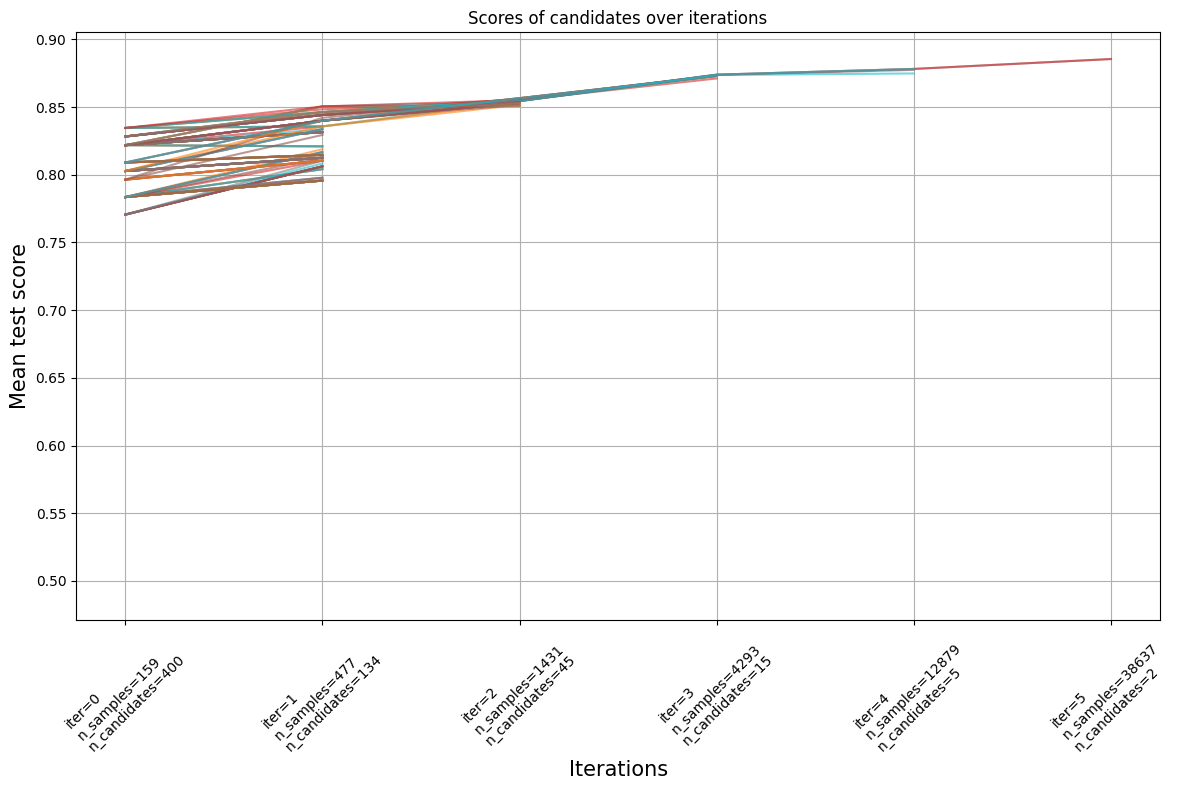

In [ ]:
plt.rcParams["figure.figsize"] = (12, 8)

results = pd.DataFrame(grid_search.cv_results_)
results["params_str"] = results.params.apply(str)
results.drop_duplicates(subset=("params_str", "iter"), inplace=True)
mean_scores = results.pivot(
    index="iter",
    columns="params_str",
     values="mean_test_score",
)
ax = mean_scores.plot(legend=False, alpha=0.6)

labels = [
    f"iter={i}\nn_samples={grid_search.n_resources_[i]}\nn_candidates={grid_search.n_candidates_[i]}"
    for i in range(grid_search.n_iterations_)
]

ax.set_xticks(range(grid_search.n_iterations_))
ax.set_xticklabels(labels, rotation=45, multialignment="left")
ax.set_title("Scores of candidates over iterations")
ax.set_ylabel("Mean test score", fontsize=15)
ax.set_xlabel("Iterations", fontsize=15)
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
grid_search.best_score_

np.float64(0.8854664914606142)

In [ ]:
preds = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

   ['cs.CV']       0.94      0.94      0.94      7004
   ['cs.LG']       0.84      0.91      0.87      5220
 ['stat.ML']       0.59      0.20      0.30       720

    accuracy                           0.89     12944
   macro avg       0.79      0.68      0.70     12944
weighted avg       0.88      0.89      0.88     12944



Сильно не улучшилось, кажется что для этой задачи лучше вообще без tf-idf

In [ ]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 4.1 MB/s eta 0:00:00


In [ ]:
import eli5

In [ ]:
grid_search.best_estimator_['clf']

LogisticRegression(C=np.float64(1.0))

In [ ]:
eli5.show_weights(
    estimator=grid_search.best_estimator_['clf'],
    feature_names=list(grid_search.best_estimator_['counter'].get_feature_names_out()),
    top=(50, 5)
)

Видно, что лучшими признаками являются термины из данной рубрики, например, "image", "vision" etc для компьютерного зрения

# Pipeline

Попробуем, как сработает метод "из коробки".

In [ ]:
%%capture
!pip install transformers

In [ ]:
from transformers import pipeline

In [ ]:
dataset['terms'].value_counts()

,count
terms,
['cs.CV'],28101
['cs.LG'],20751
['stat.ML'],2922


In [ ]:
classifier = pipeline("zero-shot-classification")
classifier(
    dataset['cleaned_text'][10],
    candidate_labels=["['cs.CV']", "['cs.LG']	", "['stat.ML']"],
)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


{'sequence': 'image segmentation algorithm depend appearance model characterize distribution pixel value different image region describe new approach estimate appearance model directly image explicit consideration pixel region approach base novel algebraic expression relate local image statistic appearance spatially coherent region describe algorithm use aforementioned algebraic expression estimate appearance model directly image algorithm solve system linear quadratic equation square formulation algorithm spectral method base eigenvector computation present experimental result demonstrate propose method work practice lead effective image segmentation algorithm',
 'labels': ["['cs.LG']\t", "['stat.ML']", "['cs.CV']"],
 'scores': [0.4054428040981293, 0.3072357773780823, 0.28732144832611084]}

In [ ]:
 dataset['terms'][10]

"['cs.CV']"

Мимо...

In [ ]:
classifier = pipeline("zero-shot-classification")
classifier(
    dataset['cleaned_text'][100],
    candidate_labels=["['cs.CV']", "['cs.LG']	", "['stat.ML']"],
)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


{'sequence': 'recent vision transformer i.e.for image classification learn non local attentive interaction different patch token prior art miss learn cross scale dependency different pixel semantic correspondence different label consistency feature representation semantic embedding critical biomedical segmentation paper tackle issue propose unify transformer network term multi compound transformer mctrans incorporate rich feature learning semantic structure mining unified framework specifically mctrans embed multi scale convolutional feature sequence token perform intra- inter scale self attention single scale attention previous work addition learnable proxy embed introduce model semantic relationship feature enhancement self attention cross attention respectively mctran easily plug unet like network attain significant improvement state art method biomedical image segmentation standard benchmark example mctrans outperform unet pannuke cvc clinic cvc colon etis kavirs isic2018 dataset r

In [ ]:
dataset['terms'][100]

"['cs.CV']"

А здесь попали...
Попробуем переписать метки

In [ ]:
classifier = pipeline("zero-shot-classification")
classifier(
    dataset['cleaned_text'][10],
    candidate_labels=["computer vision", "computer science machine learning", "statistics machine learning"],
)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


{'sequence': 'image segmentation algorithm depend appearance model characterize distribution pixel value different image region describe new approach estimate appearance model directly image explicit consideration pixel region approach base novel algebraic expression relate local image statistic appearance spatially coherent region describe algorithm use aforementioned algebraic expression estimate appearance model directly image algorithm solve system linear quadratic equation square formulation algorithm spectral method base eigenvector computation present experimental result demonstrate propose method work practice lead effective image segmentation algorithm',
 'labels': ['computer vision',
  'computer science machine learning',
  'statistics machine learning'],
 'scores': [0.44335371255874634, 0.35723307728767395, 0.1994132250547409]}

In [ ]:
classifier = pipeline("zero-shot-classification")
classifier(
    dataset['cleaned_text'][100],
    candidate_labels=["computer vision", "computer science machine learning", "statistics machine learning"],
)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


{'sequence': 'recent vision transformer i.e.for image classification learn non local attentive interaction different patch token prior art miss learn cross scale dependency different pixel semantic correspondence different label consistency feature representation semantic embedding critical biomedical segmentation paper tackle issue propose unify transformer network term multi compound transformer mctrans incorporate rich feature learning semantic structure mining unified framework specifically mctrans embed multi scale convolutional feature sequence token perform intra- inter scale self attention single scale attention previous work addition learnable proxy embed introduce model semantic relationship feature enhancement self attention cross attention respectively mctran easily plug unet like network attain significant improvement state art method biomedical image segmentation standard benchmark example mctrans outperform unet pannuke cvc clinic cvc colon etis kavirs isic2018 dataset r

In [ ]:
print(dataset['terms'][10],
dataset['terms'][100])

['cs.CV'] ['cs.CV']


А здесь попали еще лучше

# Трансформеры

In [ ]:
%%capture
!pip install datasets evaluate sentence_transformers

In [ ]:
dataset_new = dataset[['cleaned_text', 'terms']].copy()

In [ ]:
dataset_new.to_csv('cleaned_new.csv', index=False)

In [ ]:
dataset_new = pd.read_csv('cleaned_new.csv', on_bad_lines='warn')#pd.to_csv('cleaned_new.csv', index=False)

In [ ]:
dataset_new.columns = ['text','label']
# dataset_new['label'] = dataset_new['label'].astype(int)
dataset_new.describe()

,text,label
count,31049,31049
unique,24855,3
top,machine learning utilize perform task differen...,['cs.CV']
freq,5,20592


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
dataset_new['label'] = le.fit_transform(dataset_new['label'])

In [ ]:
dataset_new['label'] = dataset_new['label'].astype(float) # модель не умеет сама int -> float

In [ ]:
dataset_new['label'][0]

np.float64(0.0)

In [ ]:
from datasets import Dataset

In [ ]:
train, test = train_test_split(dataset_new, test_size=0.25, random_state=2025)
train = Dataset.from_pandas(train)
test = Dataset.from_pandas(test)

In [ ]:
from transformers import AutoTokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased") # в очищенных данных все в нижнем регистре

In [ ]:
def tokenize_function(examples):
	return tokenizer(examples['text'], padding='max_length', truncation=True)#.to(device)

tokenized_train = train.map(tokenize_function)
tokenized_test = test.map(tokenize_function)

Map:   0%|          | 0/23286 [00:00<?, ? examples/s]

Map:   0%|          | 0/7763 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=1)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments

In [ ]:
# training_args = TrainingArguments(
# 	output_dir = 'test_trainer_log',
# 	eval_strategy = 'epoch',
# 	per_device_train_batch_size = 4,
# 	per_device_eval_batch_size = 4,
# 	num_train_epochs = 3,
# 	report_to='none')

training_args = TrainingArguments(
	output_dir = 'test_trainer_log',
	eval_strategy = 'epoch',
	per_device_train_batch_size = 6,
	per_device_eval_batch_size = 6,
	num_train_epochs = 5,
	report_to='none')

'''
Как оказалось, ресусы colab ограничены, поэтому обучить больше трех эпох
не получилось...
'''

In [ ]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [ ]:
from transformers import Trainer

In [ ]:
trainer = Trainer(
	model = model,
	args = training_args,
	train_dataset = tokenized_train,
	eval_dataset = tokenized_test,
	compute_metrics = compute_metrics)

In [ ]:
import torch

In [ ]:
torch.cuda.is_available()

True

In [ ]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(device) # убедимся, что GPU работает

cuda:0


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.127200,0.114272,0.661471
2,0.154300,0.116426,0.661471
3,0.105200,0.104720,0.661471
4,0.087800,0.104122,0.661471


In [ ]:
# сохраним модель и токенизатор

save_directory1 = './save_pretrained_tok'
save_directory2 = './save_pretrained_model'
# save_directory = './pt_save_pretrained'
tokenizer.save_pretrained(save_directory1)
model.save_pretrained(save_directory2)

NameError: name 'tokenizer' is not defined

In [ ]:
from transformers import BertConfig, BertModel, BertTokenizer

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/My\ Drive/model1

Mounted at /content/gdrive
/content/gdrive/My Drive/model1


In [ ]:
# Загрузим модель

tokenizer = BertTokenizer.from_pretrained('./tokenizer/')

conf = BertConfig.from_pretrained("./model/", num_labels=1)
model_loaded = AutoModelForSequenceClassification.from_pretrained("./model/", config=conf)

In [ ]:
dataset_new.iloc[8686]

,8686
text,black box optimization bbo broad range applica...
label,1.0


In [ ]:
classifier = pipeline('text-classification', model=model_loaded, tokenizer=tokenizer)
classifier(
    dataset_new['text'][9876],
    # candidate_labels=["['cs.CV']", "['cs.LG']", "['stat.ML']"],
)
# label0 = cs.cv, label1 = cs.lg, label2 = stat.ml

Device set to use cuda:0


[{'label': 'LABEL_0', 'score': 0.3686920702457428}]

Так работает модель после дообучения... Посмотрим, как было изначально

In [ ]:
classifier_old = pipeline('text-classification', model="bert-base-uncased")
classifier_old(
    dataset_new['text'][9876],
    # candidate_labels=["['cs.CV']", "['cs.LG']", "['stat.ML']"],
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


[{'label': 'LABEL_1', 'score': 0.6075407266616821}]

Посчитаем метрики...

In [ ]:
model_old = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=1)
model_new = model_loaded

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from torch.utils.data import DataLoader

In [ ]:
small_train_dataset = train.shuffle(seed=42).select(range(1000))
small_eval_dataset = test.shuffle(seed=42).select(range(1000))

In [ ]:
tokenizer2 = AutoTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
encoding = self.tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=self.max_len,
        return_token_type_ids=False,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt',
    )

In [ ]:
train_dataloader = DataLoader(small_train_dataset, shuffle=True, batch_size=6)
eval_dataloader = DataLoader(small_eval_dataset, batch_size=6)

In [ ]:
model_old.eval()
for batch in eval_dataloader:
    # print(batch.items())
    # batch = {k: v for k, v in batch.items()}
    # print(batch['text'])
    # print(batch['labels'])
    # batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        # outputs = model_old(batch)
        outputs = model_old(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    metric.add_batch(predictions=predictions, references=batch["labels"])

metric.compute()

TypeError: BertForSequenceClassification.forward() got an unexpected keyword argument 'text'

# Выводы

- В части 1 (обычное ML) удалось построить адекватную модель на основе логистической регрессии, которая хорошо различает матки "компьютерное зрение" и другие две, отвечающие "машинному обучению", последние же две между собой различаются не очень хорошо.
- В части 2, была выбрана модель BERT. "Недообученная" версия позволяет делать адекватные предсказания, попытка же дообучить модель на своих данных видимо не удалась: с одной стороны, не хватило ресурсов (время и память в colab ограничены, не удалось обучить больше чем 3 эпохи), с другой стороны, возможно было неправильно организовано само обучение модели. В итоге, дообученная модель показывает результаты хуже.